In [1]:
import mne

raw = mne.io.read_raw_edf("data\\eeg\\sub-01\\eeg\\sub-01_task-run1_eeg.edf", preload=True)

print(raw)

Extracting EDF parameters from data\eeg\sub-01\eeg\sub-01_task-run1_eeg.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 303999  =      0.000 ...   303.999 secs...
<RawEDF | sub-01_task-run1_eeg.edf, 19 x 304000 (304.0 s), ~44.1 MiB, data loaded>


C:\Users\JULEK\AppData\Local\Temp\ipykernel_15640\1224465223.py:3: RuntimeWarning: Invalid measurement date encountered in the header.
  raw = mne.io.read_raw_edf("data\\eeg\\sub-01\\eeg\\sub-01_task-run1_eeg.edf", preload=True)


Using matplotlib as 2D backend.


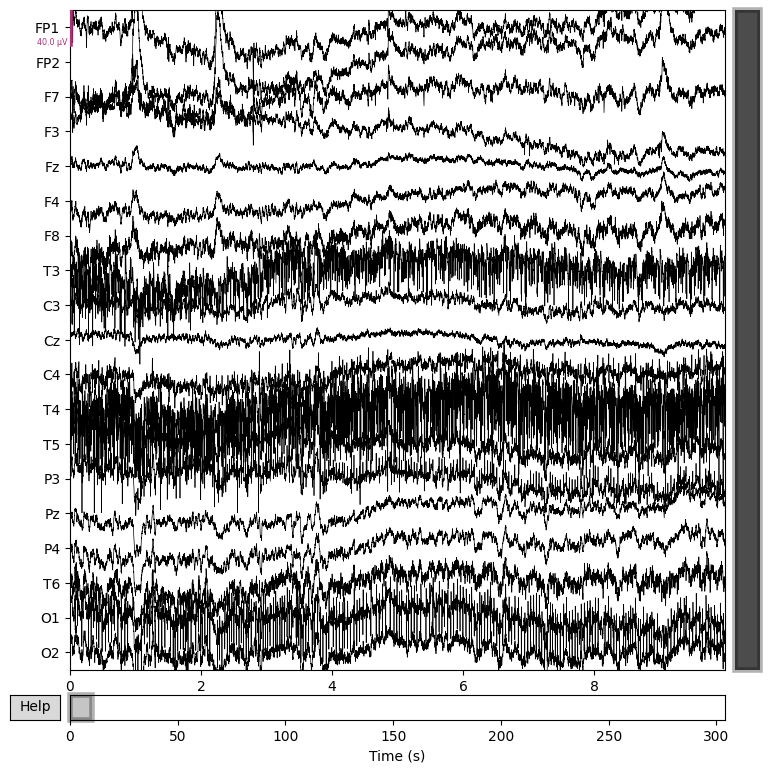

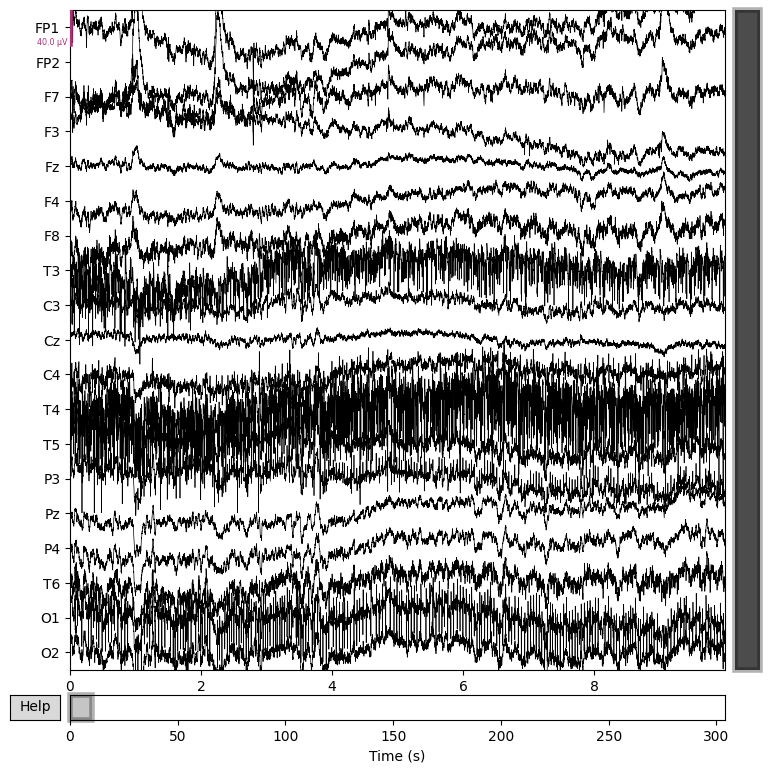

In [2]:
raw.plot()

In [3]:
import numpy as np
import scipy as sp
import pandas as pd

# pobranie danych z obiektu raw
data = raw.get_data()   # shape: (channels, samples)
channel_names = raw.ch_names
sfreq = raw.info['sfreq']

stats = []

for i, ch in enumerate(channel_names):
    signal = data[i]

    mean_val = np.mean(signal)
    std_val = np.std(signal)
    min_val = np.min(signal)
    max_val = np.max(signal)
    median_val = np.median(signal)
    var_val = np.var(signal)
    rms_val = np.sqrt(np.mean(signal**2))
    skew_val= sp.stats.skew(signal)

    stats.append({
        "channel": ch,
        "mean": mean_val,
        "std": std_val,
        "min": min_val,
        "max": max_val,
        "median": median_val,
        "variance": var_val,
        "rms": rms_val,
        "skewness": skew_val
    })

# dataframe
stats_df = pd.DataFrame(stats)

# zaokrąglenie dla czytelności
stats_df = stats_df.round(6)

print(f"Liczba kanałów: {len(channel_names)}")
print(f"Sampling rate: {sfreq} Hz")
print(f"Liczba próbek: {raw.n_times}")
print(f"Czas nagrania: {raw.times[-1]:.2f} s\n")

display(stats_df)

print("\nKanały o największej wariancji (potencjalne artefakty):")
display(stats_df.sort_values("variance", ascending=False).head(10))

Liczba kanałów: 19
Sampling rate: 1000.0 Hz
Liczba próbek: 304000
Czas nagrania: 304.00 s



,channel,mean,std,min,max,median,variance,rms,skewness
0,FP1,-0.000046,0.000070,-0.000336,0.000178,-0.000049,0.0,0.000084,-0.676571
1,FP2,0.000011,0.000053,-0.000201,0.000242,0.000007,0.0,0.000054,0.299000
2,F7,0.000018,0.000028,-0.000111,0.000159,0.000015,0.0,0.000033,0.974346
3,F3,-0.000038,0.000030,-0.000139,0.000077,-0.000038,0.0,0.000048,0.295905
4,Fz,-0.000004,0.000013,-0.000040,0.000049,-0.000005,0.0,0.000013,0.638071
5,F4,-0.000075,0.000019,-0.000126,0.000012,-0.000075,0.0,0.000077,0.445909
6,F8,-0.000115,0.000034,-0.000252,0.000043,-0.000116,0.0,0.000119,0.360540
7,T3,-0.000019,0.000025,-0.000177,0.000077,-0.000018,0.0,0.000032,-0.106474
8,C3,-0.000003,0.000012,-0.000053,0.000043,-0.000003,0.0,0.000013,0.055890
9,Cz,-0.000059,0.000011,-0.000105,-0.000024,-0.000057,0.0,0.000060,-0.284132



Kanały o największej wariancji (potencjalne artefakty):


,channel,mean,std,min,max,median,variance,rms,skewness
0,FP1,-0.000046,0.000070,-0.000336,0.000178,-0.000049,0.0,0.000084,-0.676571
1,FP2,0.000011,0.000053,-0.000201,0.000242,0.000007,0.0,0.000054,0.299000
2,F7,0.000018,0.000028,-0.000111,0.000159,0.000015,0.0,0.000033,0.974346
3,F3,-0.000038,0.000030,-0.000139,0.000077,-0.000038,0.0,0.000048,0.295905
4,Fz,-0.000004,0.000013,-0.000040,0.000049,-0.000005,0.0,0.000013,0.638071
5,F4,-0.000075,0.000019,-0.000126,0.000012,-0.000075,0.0,0.000077,0.445909
6,F8,-0.000115,0.000034,-0.000252,0.000043,-0.000116,0.0,0.000119,0.360540
7,T3,-0.000019,0.000025,-0.000177,0.000077,-0.000018,0.0,0.000032,-0.106474
8,C3,-0.000003,0.000012,-0.000053,0.000043,-0.000003,0.0,0.000013,0.055890
9,Cz,-0.000059,0.000011,-0.000105,-0.000024,-0.000057,0.0,0.000060,-0.284132


In [4]:
import pandas as pd
import json
from pprint import pprint

# --- ścieżki do plików ---
tsv_path = "data/eeg/sub-01/eeg/sub-01_task-run3_events.tsv"
json_path = "data/eeg/sub-01/eeg/sub-01_task-run3_events.json"

# --- wczytanie ---
events_df = pd.read_csv(tsv_path, sep="\t")

with open(json_path, "r", encoding="utf-8") as f:
    events_meta = json.load(f)

# ======================================
# mapowanie trial_type -> opis z json
# ======================================

trial_mapping = events_meta

long_names = []
descriptions = []
mp3_names = []

for val in events_df["trial_type"]:
    key = str(val)

    # ---------- opis z JSON ----------
    if key in trial_mapping:
        long_names.append(trial_mapping[key].get("LongName", "N/A"))
        descriptions.append(trial_mapping[key].get("Description", "N/A"))
    else:
        long_names.append("UNKNOWN")
        descriptions.append("UNKNOWN")

    # ---------- mapowanie mp3 ----------
    if 301 <= val <= 360:
        mp3_id = val - 300
        mp3_name = f"{mp3_id:03d}.mp3"
        mp3_names.append(mp3_name)
    else:
        mp3_names.append(None)

# dodanie kolumn
events_df["trial_type_LongName"] = long_names
events_df["trial_type_Description"] = descriptions
events_df["mp3_file"] = mp3_names

# ======================================
# wynik
# ======================================

print("Podgląd rozszerzonego events.tsv:\n")
display(events_df[events_df["mp3_file"].notna()])

Podgląd rozszerzonego events.tsv:



,onset,duration,trial_type,trial_type_LongName,trial_type_Description,mp3_file
5,6.535,20,306,UNKNOWN,UNKNOWN,006.mp3
522,360.077,20,303,UNKNOWN,UNKNOWN,003.mp3
593,421.513,20,332,UNKNOWN,UNKNOWN,032.mp3


In [5]:
from pathlib import Path
import pandas as pd
import re

# ==========================================
# ustaw ścieżkę główną do datasetu
# ==========================================
root_path = Path("./data/eeg")   # <- zmień

# ==========================================
# regex do parsowania nazw BIDS
# ==========================================
pattern = re.compile(
    r"sub-(?P<subject>\d+)"
    r"(?:_task-(?P<task>[a-zA-Z0-9]+))?"
    r"(?:-run(?P<run>\d+))?"
)

records = []

# ==========================================
# przeszukanie wszystkich plików
# ==========================================
for file in root_path.rglob("*"):
    if file.is_file():

        match = pattern.search(file.name)

        if match:
            subject = match.group("subject")
            task = match.group("task")
            run = match.group("run")

            records.append({
                "subject": subject,
                "task": task,
                "run": run,
                "file_type": file.suffix,
                "file_name": file.name,
                "full_path": str(file.resolve())
            })

# dataframe
files_df = pd.DataFrame(records)

# sortowanie
files_df = files_df.sort_values(
    ["subject", "task", "run", "file_type"]
).reset_index(drop=True)

print(f"Znaleziono {len(files_df)} plików")
display(files_df.head(31))

Znaleziono 925 plików


,subject,task,run,file_type,file_name,full_path
0,01,run1,None,.edf,sub-01_task-run1_eeg.edf,F:\Projekt-ABDMiB\data\eeg\sub-01\eeg\sub-01_t...
1,01,run1,None,.json,sub-01_task-run1_eeg.json,F:\Projekt-ABDMiB\data\eeg\sub-01\eeg\sub-01_t...
2,01,run1,None,.json,sub-01_task-run1_events.json,F:\Projekt-ABDMiB\data\eeg\sub-01\eeg\sub-01_t...
3,01,run1,None,.tsv,sub-01_task-run1_channels.tsv,F:\Projekt-ABDMiB\data\eeg\sub-01\eeg\sub-01_t...
4,01,run1,None,.tsv,sub-01_task-run1_events.tsv,F:\Projekt-ABDMiB\data\eeg\sub-01\eeg\sub-01_t...
5,01,run2,None,.edf,sub-01_task-run2_eeg.edf,F:\Projekt-ABDMiB\data\eeg\sub-01\eeg\sub-01_t...
6,01,run2,None,.json,sub-01_task-run2_eeg.json,F:\Projekt-ABDMiB\data\eeg\sub-01\eeg\sub-01_t...
7,01,run2,None,.json,sub-01_task-run2_events.json,F:\Projekt-ABDMiB\data\eeg\sub-01\eeg\sub-01_t...
8,01,run2,None,.tsv,sub-01_task-run2_channels.tsv,F:\Projekt-ABDMiB\data\eeg\sub-01\eeg\sub-01_t...
9,01,run2,None,.tsv,sub-01_task-run2_events.tsv,F:\Projekt-ABDMiB\data\eeg\sub-01\eeg\sub-01_t...


In [6]:
import mne

# zachowaj oryginał
raw_filtered = raw.copy()

# filtr pasmowy 1–40 Hz
raw_filtered.filter(
    l_freq=1.0,
    h_freq=40.0,
    fir_design="firwin"
)

# usunięcie zakłóceń sieci energetycznej
raw_filtered.notch_filter(
    freqs=50,
    fir_design="firwin"
)

print(raw_filtered)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 3301 samples (3.301 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edg

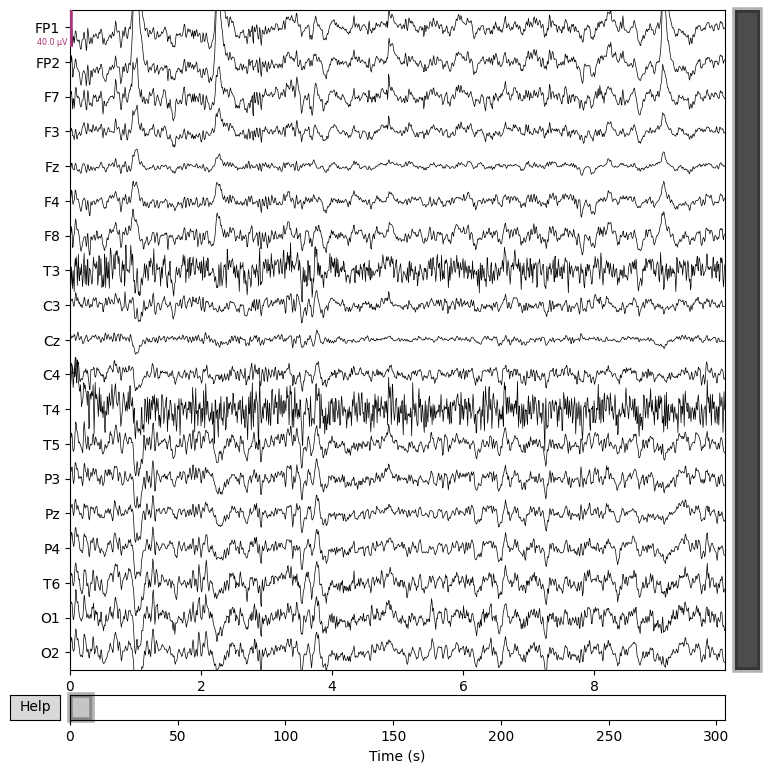

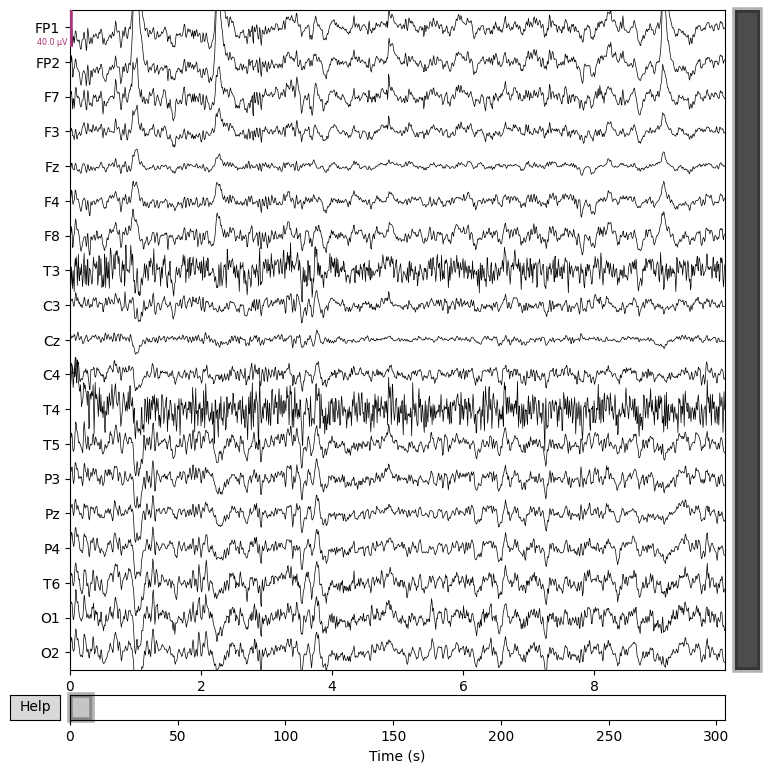

In [7]:
raw_filtered.plot()

In [8]:
bands = {
    "delta": (0.5, 4),
    "theta": (4, 8),
    "alpha": (8, 12),
    "beta": (12, 30),
    "gamma": (30, 40)
}

band_raws = {}

for band_name, (l_freq, h_freq) in bands.items():
    band_raws[band_name] = raw_filtered.copy().filter(
        l_freq=l_freq,
        h_freq=h_freq,
        fir_design="firwin",
        verbose=False
    )

print("Gotowe pasma:", list(band_raws.keys()))

Gotowe pasma: ['delta', 'theta', 'alpha', 'beta', 'gamma']


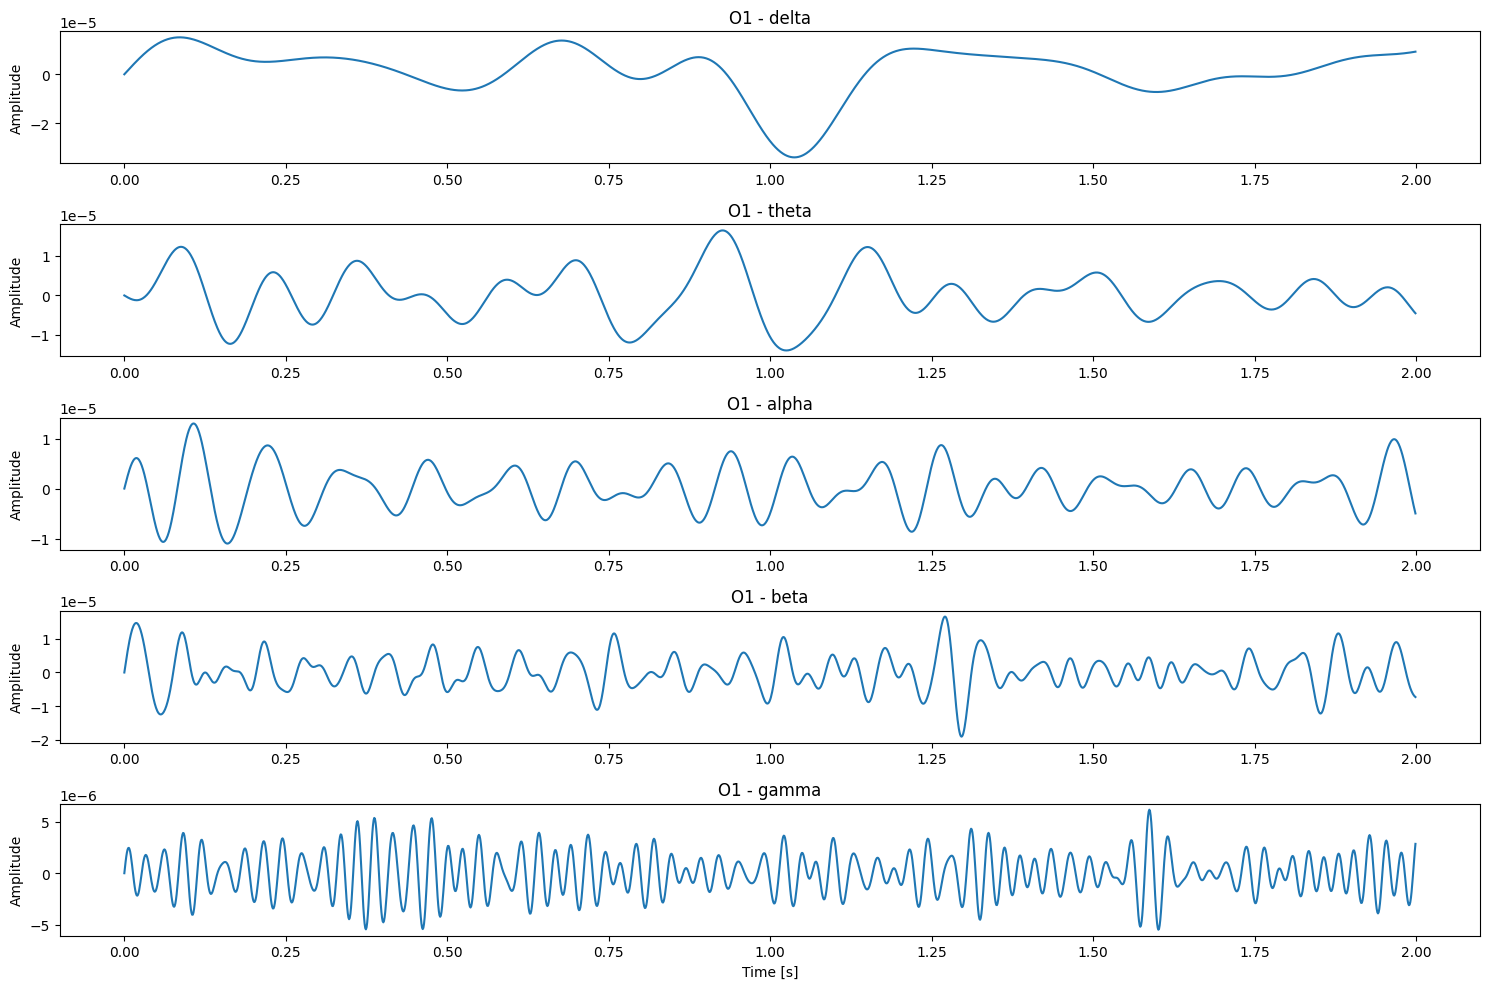

In [9]:
import matplotlib.pyplot as plt

channel = "O1"

plt.figure(figsize=(15,10))

for i, band_name in enumerate(bands.keys(), start=1):

    data, times = band_raws[band_name].get_data(
        picks=[channel],
        return_times=True
    )

    plt.subplot(len(bands), 1, i)
    plt.plot(times[:2000], data[0][:2000])
    plt.title(f"{channel} - {band_name}")
    plt.ylabel("Amplitude")

plt.xlabel("Time [s]")
plt.tight_layout()
plt.show()

In [13]:
import pandas as pd
import numpy as np
import mne
from pathlib import Path

# --------------------------------------------------
# definicje pasm
# --------------------------------------------------

bands = {
    "delta": (0.5, 4),
    "theta": (4, 8),
    "alpha": (8, 12),
    "beta":  (12, 30),
    "gamma": (30,40)
}

# --------------------------------------------------
# wyniki
# --------------------------------------------------

resting_state_rows = []

# --------------------------------------------------
# lista subjectów
# --------------------------------------------------

subjects = sorted(files_df["subject"].unique())

for subject in subjects:

    print(f"Processing subject {subject}")

    # ----------------------------------------------
    # znajdź EDF dla run1 i run6
    # ----------------------------------------------

    subject_runs = files_df[
        (files_df["subject"] == subject) &
        (files_df["file_type"] == ".edf") &
        (files_df["task"].isin(["run1", "run6"]))
    ]

    if len(subject_runs) == 0:
        print("  brak run1/run6")
        continue

    raws = []

    for _, row in subject_runs.iterrows():

        try:
            raw = mne.io.read_raw_edf(
                row["full_path"],
                preload=True,
                verbose=False
            )

            # --------------------------------------
            # filtracja podstawowa
            # --------------------------------------

            raw.filter(
                l_freq=1,
                h_freq=40,
                verbose=False
            )

            raw.notch_filter(
                freqs=50,
                verbose=False
            )

            raws.append(raw)

        except Exception as e:
            print("Błąd:", row["full_path"])
            print(e)

    if len(raws) == 0:
        continue

    # ----------------------------------------------
    # połączenie run1 + run6
    # ----------------------------------------------

    raw_rest = mne.concatenate_raws(raws)

    # ----------------------------------------------
    # obliczenia dla każdego pasma
    # ----------------------------------------------

    for band_name, (fmin, fmax) in bands.items():

        band_raw = raw_rest.copy().filter(
            l_freq=fmin,
            h_freq=fmax,
            verbose=False
        )

        data = band_raw.get_data()

        for ch_idx, ch_name in enumerate(band_raw.ch_names):

            signal = data[ch_idx]

            resting_state_rows.append({
                "subject": subject,
                "channel": ch_name,
                "band": band_name,
                "median": np.median(signal),
                "min": np.min(signal),
                "max": np.max(signal)
            })

# --------------------------------------------------
# DataFrame wynikowy
# --------------------------------------------------

resting_state_df = pd.DataFrame(resting_state_rows)

print()
print("Liczba rekordów:", len(resting_state_df))

display(resting_state_df.head())

Processing subject 01


C:\Users\JULEK\AppData\Local\Temp\ipykernel_15640\3011987646.py:53: RuntimeWarning: Invalid measurement date encountered in the header.
  raw = mne.io.read_raw_edf(
C:\Users\JULEK\AppData\Local\Temp\ipykernel_15640\3011987646.py:53: RuntimeWarning: Invalid measurement date encountered in the header.
  raw = mne.io.read_raw_edf(


Processing subject 02


C:\Users\JULEK\AppData\Local\Temp\ipykernel_15640\3011987646.py:53: RuntimeWarning: Invalid measurement date encountered in the header.
  raw = mne.io.read_raw_edf(
C:\Users\JULEK\AppData\Local\Temp\ipykernel_15640\3011987646.py:53: RuntimeWarning: Invalid measurement date encountered in the header.
  raw = mne.io.read_raw_edf(


Processing subject 03


...

C:\Users\JULEK\AppData\Local\Temp\ipykernel_15640\3011987646.py:53: RuntimeWarning: Invalid measurement date encountered in the header.
  raw = mne.io.read_raw_edf(
C:\Users\JULEK\AppData\Local\Temp\ipykernel_15640\3011987646.py:53: RuntimeWarning: Invalid measurement date encountered in the header.
  raw = mne.io.read_raw_edf(


Processing subject 31


C:\Users\JULEK\AppData\Local\Temp\ipykernel_15640\3011987646.py:53: RuntimeWarning: Invalid measurement date encountered in the header.
  raw = mne.io.read_raw_edf(
C:\Users\JULEK\AppData\Local\Temp\ipykernel_15640\3011987646.py:53: RuntimeWarning: Invalid measurement date encountered in the header.
  raw = mne.io.read_raw_edf(



Liczba rekordów: 2945


,subject,channel,band,median,min,max
0,01,FP1,delta,-1.519127e-06,-0.000126,0.000154
1,01,FP2,delta,-1.497261e-06,-0.000130,0.000146
2,01,F7,delta,-6.652664e-07,-0.000095,0.000091
3,01,F3,delta,-4.259217e-07,-0.000050,0.000050
4,01,Fz,delta,-3.044709e-07,-0.000027,0.000028


In [14]:
resting_state_df.tail(10)

,subject,channel,band,median,min,max
2935,31,Cz,gamma,4.828990e-10,-0.000008,0.000008
2936,31,C4,gamma,2.248207e-09,-0.000016,0.000016
2937,31,T4,gamma,2.714873e-09,-0.000028,0.000028
2938,31,T5,gamma,1.871819e-09,-0.000021,0.000021
2939,31,P3,gamma,1.190953e-09,-0.000017,0.000018
2940,31,Pz,gamma,1.284070e-09,-0.000018,0.000018
2941,31,P4,gamma,1.513137e-09,-0.000019,0.000019
2942,31,T6,gamma,3.001815e-09,-0.000023,0.000021
2943,31,O1,gamma,2.184063e-09,-0.000029,0.000026
2944,31,O2,gamma,2.715378e-09,-0.000044,0.000041
